### Regression modeling of cryptocurrencies

I want to see if we can come up with a predictive model for the next day cryptocurrency return using different statistical techniques. 
Different types of regression models to play with: 
* Simple rolling linear regression (using some lookback)
* Machine learning models using different indicators coming from price
  * Support Vector Machines
  * Linear Regression with regularization
  * Decision Tree Regression / Random Forest
  * Boosting
  


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

# Loading internal modules
from coinbase_crypto.pricing_data import PricingDataLoader
from helperfuncs import load_aws_keys
from regression import UnivariateRegressionModel
from model_validation import create_tsplit_indices

# Importing machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Regular importing packages

keys = load_aws_keys()
# data_loader = PricingDataLoader(keys.api_key, keys.secret_key)

In [2]:
# Getting all the data into daily candles
coin = 'BTC'
filepath = "pricing_data/{}_daily_data.csv".format(coin)
candles = pd.read_csv(filepath)

What is the linear relationship the past 1 day return, N-days ago and the return that we see now? Is there a real relationship that we can exploit?

In [3]:
candles['LOG_CLOSE_PRICE'] = candles['CLOSE'].apply(np.log)
candles['DAILY_LOG_RETURN'] = candles['LOG_CLOSE_PRICE'].diff()

# Creating a series of log returns
period_shifts = list(range(1, 6))
for period_shift in period_shifts: 
    candles[f'{period_shift}_DAYS_PREV_LOG_RETURN'] = candles['DAILY_LOG_RETURN'].shift(period_shift)

candles.set_index('TIME', inplace = True)
candles.dropna(inplace = True)

In [4]:
num_past_observations = 90
prev_period = 1
X = candles[f'{prev_period}_DAYS_PREV_LOG_RETURN'].iloc[-num_past_observations-1:].values.reshape(-1, 1)
y = candles['DAILY_LOG_RETURN'].iloc[-num_past_observations-1:].values.reshape(-1, 1)

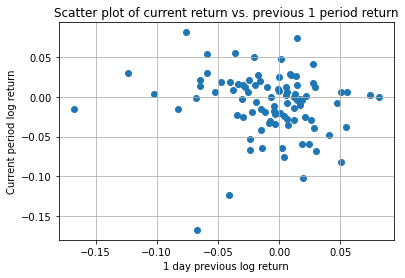

In [5]:
plt.scatter(X, y)
plt.title("Scatter plot of current return vs. previous 1 period return")
plt.xlabel("{} day previous log return".format(prev_period))
plt.ylabel("Current period log return")
plt.grid(True)

In [6]:
regression_model = UnivariateRegressionModel(X, y)
regression_model.show_summary()



        The beta for the regression is -0.13
        The r^2 is 0.017
        The correlation is 0.13
        


We have a simple regression model where we look at the past day's return and try to predict tomorrow's return. How well does that model do? 

In [76]:
squared_errors = []
absolute_errors = []
feature_columns = [f'{prev_period}_DAYS_PREV_LOG_RETURN' for prev_period in range(1, 6)]
results = {}
target_column = 'DAILY_LOG_RETURN'

for feature_column in feature_columns: 
    # Creating the indices of the rolling time series split
    split_indices = create_tsplit_indices(df = candles)
    for train_indices, test_indices in split_indices: 

        train_X = candles[feature_column].iloc[train_indices]
        test_X = candles[feature_column].iloc[test_indices]
        train_y = candles[target_column].iloc[train_indices]
        test_y = candles[target_column].iloc[test_indices]

        reg = UnivariateRegressionModel(X = train_X.values.reshape(-1, 1), y = train_y.values.reshape(-1, 1))
        reg_test_predictions = reg.predict(test_X.values.reshape(-1, 1))
        squared_error = mean_squared_error(y_true = test_y.values.reshape(-1, 1), y_pred = reg_test_predictions) 
        absolute_error = mean_absolute_error(y_true = test_y.values.reshape(-1, 1), y_pred = reg_test_predictions)

        squared_errors.append(squared_error)
        absolute_errors.append(absolute_error)

    mse_array = np.array(squared_errors) 
    mae_array = np.array(absolute_errors)

    regression_mse = mse_array.mean()
    regression_mae = mae_array.mean()

    results[feature_column] = {'mse': regression_mse, 'mae': regression_mae}

In [77]:
results

{'1_DAYS_PREV_LOG_RETURN': {'mse': 0.0016051368607716936,
  'mae': 0.02668954540111396},
 '2_DAYS_PREV_LOG_RETURN': {'mse': 0.0016054946891441494,
  'mae': 0.026641156993972834},
 '3_DAYS_PREV_LOG_RETURN': {'mse': 0.0016097155452219152,
  'mae': 0.02670151692729905},
 '4_DAYS_PREV_LOG_RETURN': {'mse': 0.0016269974230880945,
  'mae': 0.02681276415344209},
 '5_DAYS_PREV_LOG_RETURN': {'mse': 0.0016279779692751227,
  'mae': 0.0268285360494068}}

Here, I tested using a regression on the previous 90 days of lagged returns and testing that model on the one-day out of sample return. It would be expected that I refit the model every day using the previous 90 days of features so that I can predict tomorrow. we can see that the MAE for this model is about 2.7% which means on average you are off about 2.7% from where you would have liked to be on the return. This of course is only one statistic that is characterizing the distribution of the residuals. Let's take a look at that distribution to see if there is anything of note. 